In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df = pd.read_csv('train.csv')
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [7]:
print(df.columns.tolist()[-3:])

['LONGITUDE', 'LATITUDE', 'TARGET(PRICE_IN_LACS)']


In [8]:
print(df.isnull().sum())
df.describe()

POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64


,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


In [9]:
# Check how many extreme outliers exist
print((df['SQUARE_FT'] > 10000).sum())

# Cap unrealistic square footage (anything above 10,000 sqft is almost certainly an error for this dataset)
df = df[df['SQUARE_FT'] <= 10000]
print("New shape:", df.shape)

189
New shape: (29262, 12)


In [10]:
df_model = df.drop(columns=['ADDRESS'])

df_model = pd.get_dummies(df_model, columns=['POSTED_BY', 'BHK_OR_RK'], drop_first=True)

df_model.head()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS),POSTED_BY_Dealer,POSTED_BY_Owner,BHK_OR_RK_RK
0,0,0,2,1300.236407,1,1,12.969910,77.597960,55.0,False,True,False
1,0,0,2,1275.000000,1,1,12.274538,76.644605,51.0,True,False,False
2,0,0,2,933.159722,1,1,12.778033,77.632191,43.0,False,True,False
3,0,1,2,929.921143,1,1,28.642300,77.344500,62.5,False,True,False
4,1,0,2,999.009247,0,1,22.592200,88.484911,60.5,True,False,False


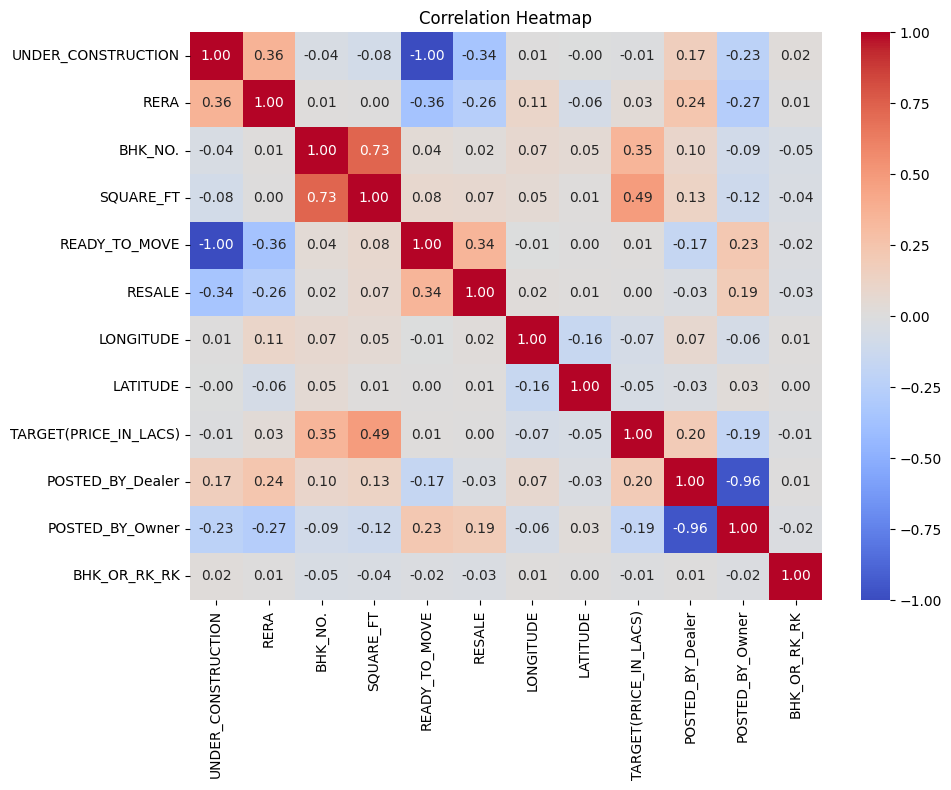

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df_model.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [12]:
df_model = df_model.drop(columns=['READY_TO_MOVE'])  # redundant with UNDER_CONSTRUCTION

X = df_model.drop(columns=['TARGET(PRICE_IN_LACS)'])
y = df_model['TARGET(PRICE_IN_LACS)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 16374.234684278881
RMSE: 127.961848549788
R² Score: 0.34904229430129186


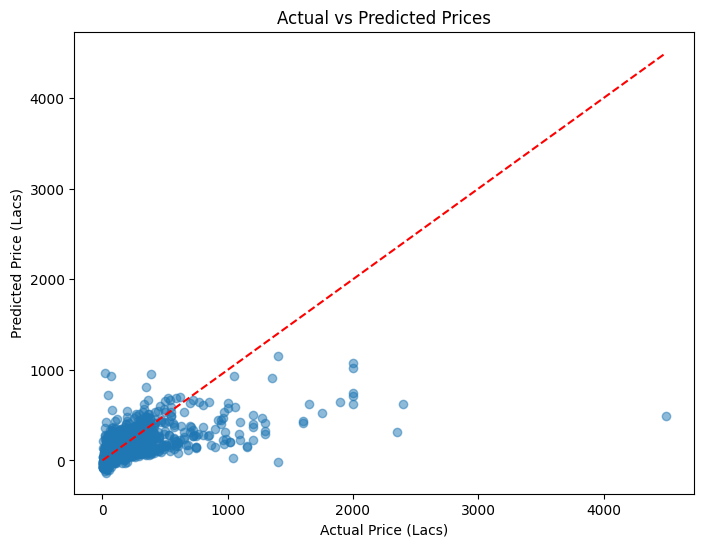

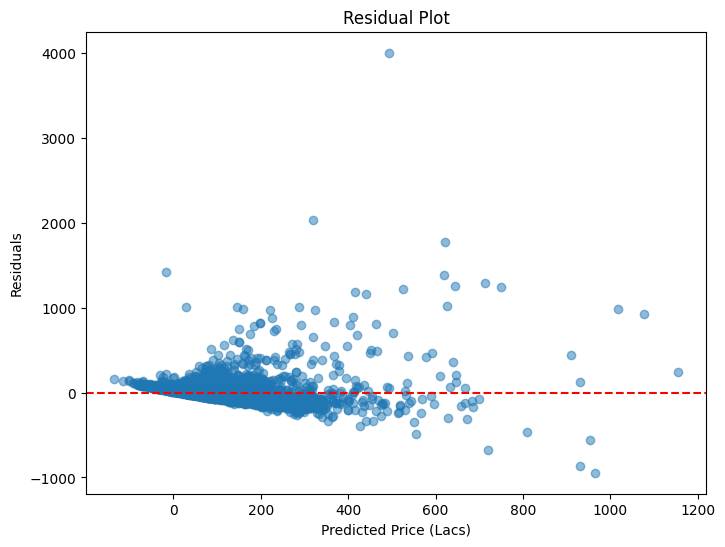

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price (Lacs)')
plt.ylabel('Predicted Price (Lacs)')
plt.title('Actual vs Predicted Prices')
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price (Lacs)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [14]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

              Feature  Coefficient
7    POSTED_BY_Dealer    70.997555
9        BHK_OR_RK_RK    64.669101
8     POSTED_BY_Owner    16.285839
2             BHK_NO.     1.194693
3           SQUARE_FT     0.122077
1                RERA    -0.853927
6            LATITUDE    -1.350337
0  UNDER_CONSTRUCTION    -1.555621
5           LONGITUDE    -3.396514
4              RESALE   -20.025783


# Conclusion:
The Linear Regression model achieved an R² of 0.35, meaning it explains about 35% of the variance in house prices — a modest fit. SQUARE_FT and BHK_NO. were the most useful continuous predictors, while RESALE status had the strongest negative impact, with resale homes priced notably lower than new listings. Dealer-listed properties tend to command higher prices than owner or builder listings. The relatively low R² suggests important price-driving factors (build quality, amenities, exact neighborhood, market demand) aren't captured in this dataset a more complete feature set or a non-linear model (e.g., Random Forest) would likely improve predictive accuracy.